In [1]:
import numpy as np
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cloudpickle
import base64
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from joblib import Parallel, delayed
from scipy.stats import vonmises_fisher, vonmises_line

## Functions

In [2]:
def spd_coverage_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'train_size', 'df', 'ai_i_cov', 'ai_ii_cov', 'ai_iii_cov', 'ai_iv_cov',
    'lc_i_cov', 'lc_ii_cov', 'lc_iii_cov', 'lc_iv_cov', 'le_i_cov', 'le_ii_cov', 'le_iii_cov', 'le_iv_cov',
    'ai_OOB_quantile', 'lc_OOB_quantile', 'le_OOB_quantile'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_SPD'), 'results')):
        if (file.endswith('.npy')):# and file.split('_')[3][5:] == '100'):
            print(i)
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_SPD'), 'results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'train_size': int(file.split('_')[2][1:]),
            'df': file.split('_')[3][2:],
            'ai_i_cov': [result['ai_i_cov']],
            'ai_ii_cov': [result['ai_ii_cov']],
            'ai_iii_cov': [result['ai_iii_cov']],
            'ai_iv_cov': [result['ai_iv_cov']],
            'lc_i_cov': [result['lc_i_cov']],
            'lc_ii_cov': [result['lc_ii_cov']],
            'lc_iii_cov': [result['lc_iii_cov']],
            'lc_iv_cov': [result['lc_iv_cov']],
            'le_i_cov': [result['le_i_cov']],
            'le_ii_cov': [result['le_ii_cov']],
            'le_iii_cov': [result['le_iii_cov']],
            'le_iv_cov': [result['le_iv_cov']],
            'ai_OOB_quantile': [result['ai_OOB_quantile']],
            'lc_OOB_quantile': [result['lc_OOB_quantile']],
            'le_OOB_quantile': [result['le_OOB_quantile']]
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    coverage_df['train_size'] = coverage_df['train_size'].astype('category')
    coverage_df['df'] = coverage_df.df.astype('category')
    return coverage_df

# Parameters
sample_sizes = [50, 100, 200, 500]  # Sample sizes
df_values = [5, 15]  # Concentration parameters
q = 2

Prediction balls

In [3]:
# Define confidence levels
np.random.seed(1000)
sign_level = np.array([0.01, 0.05, 0.1])
# Load stored results
SPD_coverage_df=spd_coverage_results()
SPD_coverage_df.head()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59


,sample_index,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,lc_i_cov,lc_ii_cov,lc_iii_cov,lc_iv_cov,le_i_cov,le_ii_cov,le_iii_cov,le_iv_cov,ai_OOB_quantile,lc_OOB_quantile,le_OOB_quantile
0,10,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.942, 0.896, 0.85]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.972, 0.928, 0.898]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.974, 0.892, 0.846]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.936, 0.9]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.934, 0.888, 0.866]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.964, 0.926, 0.898]","[1.209174232199228, 1.0588290924600106, 0.9868...","[0.7408045846925754, 0.6077022055194831, 0.565...","[1.1756232696684343, 1.0431142652534608, 0.990..."
1,9,200,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.98, 0.914, 0.872]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.976, 0.898, 0.854]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.936, 0.88]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.954, 0.878]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.972, 0.904, 0.866]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.962, 0.884, 0.848]","[2.8389905267191113, 2.107809354948287, 1.8692...","[1.5326626610654412, 1.280193348339678, 1.0793...","[2.5913555974288798, 1.9896913313741322, 1.856..."
2,7,200,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.982, 0.95]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.976, 0.944]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.972, 0.928]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.97, 0.924]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.984, 0.948]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.976, 0.94]","[3.5276670008419857, 2.59455212529543, 2.12713...","[1.7015769798733156, 1.345368405857848, 1.1219...","[3.5108620703648774, 2.598060878399219, 2.0738..."
3,2,50,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.912, 0.888]","[[1.0, 1.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.978, 0.974]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.914, 0.85]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.982, 0.956]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.9, 0.872]","[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.974, 0.952]","[1.8497813111487396, 1.3308158676292443, 1.259...","[1.0162691198908336, 0.808523405828447, 0.6878...","[1.7478820319905757, 1.2700428845237899, 1.200..."
4,3,100,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.972, 0.892, 0.806]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.958, 0.88]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.98, 0.92, 0.81]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.972, 0.906]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.932, 0.86]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.966, 0.908]","[2.706004139432247, 2.0986732666577095, 1.7648...","[1.4966560133364901, 1.248654580192308, 1.0093...","[2.8176861409251632, 2.3125230196573456, 1.885..."


In [4]:
ai_SPD_coverage_df = SPD_coverage_df[['train_size', 'df', 'ai_i_cov', 'ai_ii_cov', 'ai_iii_cov', 'ai_iv_cov', 'ai_OOB_quantile']]
lc_SPD_coverage_df = SPD_coverage_df[['train_size', 'df', 'lc_i_cov', 'lc_ii_cov', 'lc_iii_cov', 'lc_iv_cov', 'lc_OOB_quantile']]
le_SPD_coverage_df = SPD_coverage_df[['train_size', 'df', 'le_i_cov', 'le_ii_cov', 'le_iii_cov', 'le_iv_cov', 'le_OOB_quantile']]

# TYPE I

In [5]:
import pandas as pd
import numpy as np

zeros_init = np.zeros((50, 3))

def calculate_type_i_coverage(SPD_coverage_df, sample_sizes, df_values):
    # Initialize a list to store the means for each row (50 rows of 3 means)
    ai_diccionario_i = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    lc_diccionario_i = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    le_diccionario_i = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    for N in sample_sizes:
        for df in df_values:
            ai_means = []
            lc_means = []
            le_means = []
            ai_SPD_coverage_df_N_df = ai_SPD_coverage_df[(ai_SPD_coverage_df['df'] == str(df))
             & (ai_SPD_coverage_df['train_size'] == N)]
            lc_SPD_coverage_df_N_df = lc_SPD_coverage_df[(lc_SPD_coverage_df['df'] == str(df))
             & (lc_SPD_coverage_df['train_size'] == N)]
            le_SPD_coverage_df_N_df = le_SPD_coverage_df[(le_SPD_coverage_df['df'] == str(df))
             & (le_SPD_coverage_df['train_size'] == N)]
            # Loop through each of the 50 rows (indices 0 through 49)
            for i in range(50):
                # Extract the i-th row from each 50x3 DataFrame in SPD_coverage_df['i_cov']
                ai_row_data = ai_SPD_coverage_df_N_df['ai_i_cov'].apply(lambda df: df[i])
                lc_row_data = lc_SPD_coverage_df_N_df['lc_i_cov'].apply(lambda df: df[i])
                le_row_data = le_SPD_coverage_df_N_df['le_i_cov'].apply(lambda df: df[i])
                # Calculate the mean of the 3 columns for this row (axis=0 is for columns)
                ai_row_mean = ai_row_data.mean(axis=0)
                lc_row_mean = lc_row_data.mean(axis=0)
                le_row_mean = le_row_data.mean(axis=0)
                # Append the mean of this row (3 values) to the list
                ai_means.append(ai_row_mean)
                lc_means.append(lc_row_mean)
                le_means.append(le_row_mean)

            ai_diccionario_i['df_' + str(df)][str(N)] = ai_means
            lc_diccionario_i['df_' + str(df)][str(N)] = lc_means
            le_diccionario_i['df_' + str(df)][str(N)] = le_means
    # mean_df now contains the 50x3 means where each row corresponds to a row of means for the respective 
    return ai_diccionario_i, lc_diccionario_i, le_diccionario_i

sample_sizes = [50, 100, 200, 500]  # Sample sizes
df_values = [5, 15]  # Concentration parameters

ai_diccionario_i, lc_diccionario_i, le_diccionario_i = calculate_type_i_coverage(SPD_coverage_df = SPD_coverage_df, sample_sizes = sample_sizes, df_values = df_values)
le_diccionario_i

{'df_5': {'50': [array([1. , 1. , 0.8]),
   array([1. , 0.8, 0.8]),
   array([0.9, 0.8, 0.7]),
   array([0.9, 0.9, 0.9]),
   array([1. , 0.9, 0.8]),
   array([1. , 1. , 0.9]),
   array([1. , 0.9, 0.9]),
   array([0.9, 0.9, 0.8]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.8]),
   array([1. , 1. , 0.8]),
   array([1. , 0.9, 0.9]),
   array([0.9, 0.9, 0.9]),
   array([0.9, 0.8, 0.8]),
   array([0.8, 0.8, 0.7]),
   array([1., 1., 1.]),
   array([1. , 0.9, 0.9]),
   array([1. , 1. , 0.9]),
   array([1. , 1. , 0.9]),
   array([1. , 1. , 0.9]),
   array([0.9, 0.9, 0.8]),
   array([0.9, 0.8, 0.8]),
   array([1. , 1. , 0.9]),
   array([1. , 0.9, 0.9]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.9]),
   array([0.9, 0.9, 0.8]),
   array([1. , 0.9, 0.9]),
   array([0.9, 0.9, 0.8]),
   array([0.9, 0.9, 0.9]),
   array([0.8, 0.8, 0.8]),
   array([0.6, 0.6, 0.6]),
   array([0.9, 0.9, 0.7]),
   array([1. , 0.9, 0.7]),
   array([1., 1., 1.]),
  

Prediction balls

In [44]:
def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

In [49]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_ai = np.mean(ai_diccionario_i[f'df_{df}'][str(N)], axis=0)
        stds_ai = np.sqrt(np.var(ai_diccionario_i[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_ai[i]:.2f} ({100*stds_ai[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
ai_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
ai_df

Significance Level          0.01          0.05            0.1
df N                                                         
5  50               98.40 (3.67)  91.80 (7.92)   87.80 (9.44)
   100              97.00 (5.00)  93.80 (7.45)   89.40 (8.81)
   200              98.80 (3.25)  96.00 (6.63)   90.00 (9.59)
   500              99.00 (3.00)  94.60 (8.05)  90.40 (11.48)
15 50               97.60 (4.27)  92.80 (7.22)   88.60 (9.38)
   100              97.80 (4.60)  92.40 (7.36)   87.80 (9.23)
   200              97.60 (4.72)  92.00 (9.59)  88.20 (10.52)
   500              98.20 (3.84)  93.80 (7.45)   87.40 (9.76)

In [50]:
# Apply formatting to all cells
ai_df = ai_df.applymap(format_cell)
ai_latex = ai_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:ai_typeIerrorcoverage')
print(ai_latex)

\begin{table}
\caption{Type I error}
\label{tab:ai_typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.40 (3.67) & 91.80 (7.92) & 87.80 (9.44) \\
\textbf{} & \textbf{100} & 97.00 (5.00) & 93.80 (7.45) & 89.40 (8.81) \\
\textbf{} & \textbf{200} & 98.80 (3.25) & 96.00 (6.63) & 90.00 (9.59) \\
\textbf{} & \textbf{500} & 99.00 (3.00) & 94.60 (8.05) & 90.40 (11.48) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 97.60 (4.27) & 92.80 (7.22) & 88.60 (9.38) \\
\textbf{} & \textbf{100} & 97.80 (4.60) & 92.40 (7.36) & 87.80 (9.23) \\
\textbf{} & \textbf{200} & 97.60 (4.72) & 92.00 (9.59) & 88.20 (10.52) \\
\textbf{} & \textbf{500} & 98.20 (3.84) & 93.80 (7.45) & 87.40 (9.76) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/1377484444.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ai_df = ai_df.applymap(format_cell)


In [52]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_lc = np.mean(lc_diccionario_i[f'df_{df}'][str(N)], axis=0)
        stds_lc = np.sqrt(np.var(lc_diccionario_i[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_lc[i]:.2f} ({100*stds_lc[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
lc_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
lc_df

Significance Level          0.01          0.05            0.1
df N                                                         
5  50               98.80 (3.25)  93.40 (7.10)   87.20 (8.73)
   100              98.40 (3.67)  94.00 (7.21)   88.60 (9.59)
   200              99.40 (2.37)  96.00 (6.63)   92.20 (8.78)
   500              99.40 (2.37)  93.80 (8.46)  88.20 (10.33)
15 50               98.20 (3.84)  94.80 (6.08)   91.00 (6.40)
   100              98.40 (3.67)  93.00 (7.81)  89.20 (10.17)
   200              98.20 (3.84)  92.20 (8.78)  86.20 (11.12)
   500              98.60 (3.47)  94.40 (6.37)   87.80 (9.86)

In [53]:
# Apply formatting to all cells
lc_df = lc_df.applymap(format_cell)
lc_latex = lc_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:lc_typeIerrorcoverage')
print(lc_latex)

\begin{table}
\caption{Type I error}
\label{tab:lc_typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.80 (3.25) & 93.40 (7.10) & 87.20 (8.73) \\
\textbf{} & \textbf{100} & 98.40 (3.67) & 94.00 (7.21) & 88.60 (9.59) \\
\textbf{} & \textbf{200} & 99.40 (2.37) & 96.00 (6.63) & 92.20 (8.78) \\
\textbf{} & \textbf{500} & 99.40 (2.37) & 93.80 (8.46) & 88.20 (10.33) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 98.20 (3.84) & 94.80 (6.08) & 91.00 (6.40) \\
\textbf{} & \textbf{100} & 98.40 (3.67) & 93.00 (7.81) & 89.20 (10.17) \\
\textbf{} & \textbf{200} & 98.20 (3.84) & 92.20 (8.78) & 86.20 (11.12) \\
\textbf{} & \textbf{500} & 98.60 (3.47) & 94.40 (6.37) & 87.80 (9.86) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/1770482267.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  lc_df = lc_df.applymap(format_cell)


In [55]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_le = np.mean(le_diccionario_i[f'df_{df}'][str(N)], axis=0)
        stds_le = np.sqrt(np.var(le_diccionario_i[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_le[i]:.2f} ({100*stds_le[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
le_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
le_df

Significance Level          0.01          0.05            0.1
df N                                                         
5  50               98.00 (4.00)  92.60 (7.70)   87.80 (9.23)
   100              97.00 (5.00)  93.60 (7.42)   88.40 (9.46)
   200              98.60 (3.47)  96.00 (6.63)   90.20 (9.27)
   500              99.00 (3.00)  94.80 (8.30)  89.60 (11.99)
15 50               97.00 (5.00)  93.40 (6.81)   88.80 (9.09)
   100              97.60 (4.72)  93.20 (7.05)   87.60 (9.50)
   200              97.40 (4.82)  92.40 (9.50)  88.00 (10.20)
   500              98.20 (4.33)  93.60 (7.68)   88.00 (9.17)

In [12]:
# Apply formatting to all cells
le_df = le_df.applymap(format_cell)
le_latex = le_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:ai_typeIerrorcoverage')
print(le_latex)

\begin{table}
\caption{Type I error}
\label{tab:ai_typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{2}{*}{\textbf{5}} & \textbf{100} & 96.00 (19.60) & 94.00 (23.75) & 88.00 (32.50) \\
\textbf{} & \textbf{200} & 98.00 (9.80) & 92.00 (18.33) & 87.00 (21.93) \\
\cline{1-5}
\multirow[t]{2}{*}{\textbf{15}} & \textbf{100} & 99.50 (3.50) & 93.00 (14.18) & 91.00 (14.80) \\
\textbf{} & \textbf{200} & 100.00 (0.00) & 96.00 (13.56) & 91.00 (19.21) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/691899972.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  le_df = le_df.applymap(format_cell)


# TYPE II

### df 5

In [56]:
ai_ii_SPD_coverage_df_df_5_alpha_01 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()
ai_ii_SPD_coverage_df_df_5_alpha_05 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()
ai_ii_SPD_coverage_df_df_5_alpha_1  = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()

lc_ii_SPD_coverage_df_df_5_alpha_01 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()
lc_ii_SPD_coverage_df_df_5_alpha_05 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()
lc_ii_SPD_coverage_df_df_5_alpha_1  = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()

le_ii_SPD_coverage_df_df_5_alpha_01 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()
le_ii_SPD_coverage_df_df_5_alpha_05 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()
le_ii_SPD_coverage_df_df_5_alpha_1  = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()

ai_ii_SPD_coverage_df_df_5_alpha_01['ai_ii_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_ii_cov'].apply(lambda x: x[0])
ai_ii_SPD_coverage_df_df_5_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[0])

lc_ii_SPD_coverage_df_df_5_alpha_01['lc_ii_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_ii_cov'].apply(lambda x: x[0])
lc_ii_SPD_coverage_df_df_5_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[0])

le_ii_SPD_coverage_df_df_5_alpha_01['le_ii_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_ii_cov'].apply(lambda x: x[0])
le_ii_SPD_coverage_df_df_5_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[0])

ai_ii_SPD_coverage_df_df_5_alpha_05['ai_ii_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_ii_cov'].apply(lambda x: x[1])
ai_ii_SPD_coverage_df_df_5_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[1])

lc_ii_SPD_coverage_df_df_5_alpha_05['lc_ii_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_ii_cov'].apply(lambda x: x[1])
lc_ii_SPD_coverage_df_df_5_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[1])

le_ii_SPD_coverage_df_df_5_alpha_05['le_ii_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_ii_cov'].apply(lambda x: x[1])
le_ii_SPD_coverage_df_df_5_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[1])

ai_ii_SPD_coverage_df_df_5_alpha_1['ai_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_ii_cov'].apply(lambda x: x[2])
ai_ii_SPD_coverage_df_df_5_alpha_1['ai_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[2])

lc_ii_SPD_coverage_df_df_5_alpha_1['lc_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['lc_ii_cov'].apply(lambda x: x[2])
lc_ii_SPD_coverage_df_df_5_alpha_1['lc_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[2])

le_ii_SPD_coverage_df_df_5_alpha_1['le_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['le_ii_cov'].apply(lambda x: x[2])
le_ii_SPD_coverage_df_df_5_alpha_1['le_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[2])

ai_ii_SPD_coverage_df_df_5_alpha_01.head()
ai_ii_SPD_coverage_df_df_5_alpha_05.head()
ai_ii_SPD_coverage_df_df_5_alpha_1.head()

,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,ai_OOB_quantile
1,200,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.876,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.978, 0.916, 0.882]",1.783701
2,200,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.884,"[[1.0, 1.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.952, 0.866]",1.865951
4,100,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.934,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.976, 0.97, 0.922]",2.054094
5,500,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.894,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.942, 0.914]",1.950285
10,50,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.848,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.926, 0.792]",1.765177


/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/1667783737.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['200'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


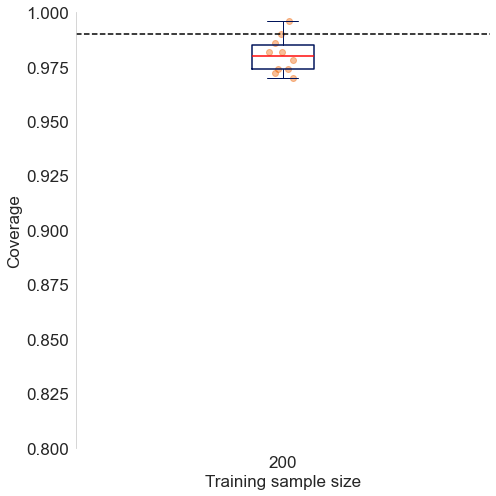

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/1667783737.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['200'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


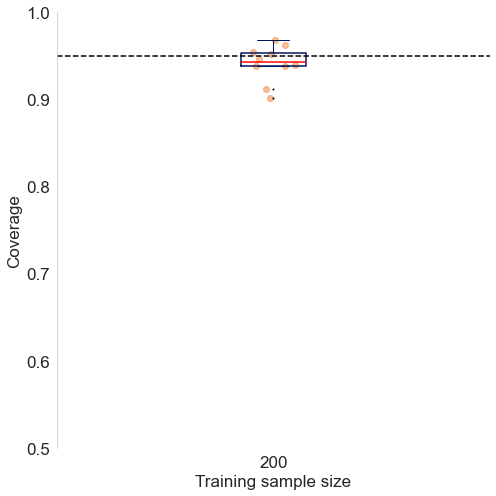

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/1667783737.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['200'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


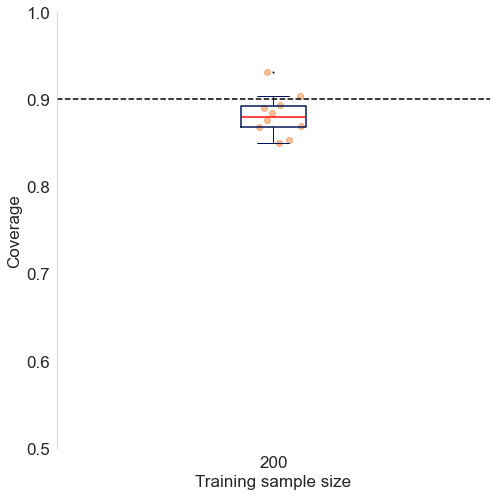

In [57]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')

capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([ai_ii_SPD_coverage_df_df_5_alpha_01, ai_ii_SPD_coverage_df_df_5_alpha_05, ai_ii_SPD_coverage_df_df_5_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)
    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    #data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    #data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        #'50': data_50['ai_ii_cov'].values,
        #'100': data_100['ai_ii_cov'].values,
        '200': data_200['ai_ii_cov'].values,
        #'500': data_500['ai_ii_cov'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    #sns.boxplot(data = data, x='train_size', y='II_coverage',
               # flierprops={"marker": "x"}, dodge=True, showmeans=True, meanprops={'marker':'o','markerfacecolor':'white','markeredgecolor':'white','markersize':'4'})

    ax.boxplot(boxplot_data, labels = ['200'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/ai_df_5_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/1245822414.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['200'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


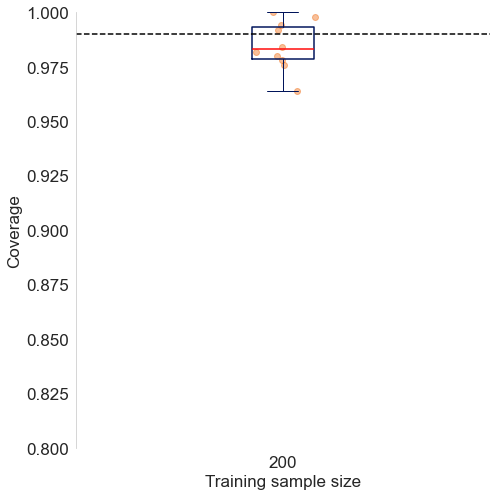

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/1245822414.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['200'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


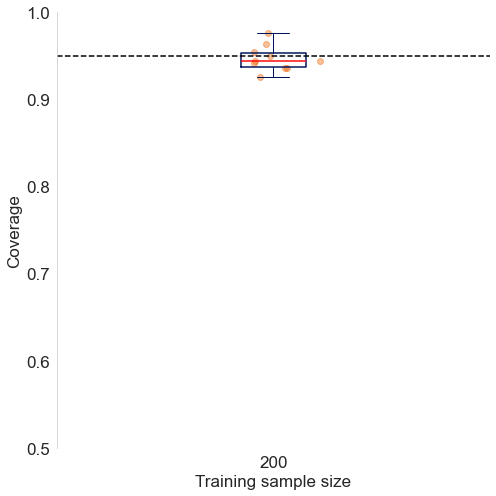

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/1245822414.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['200'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


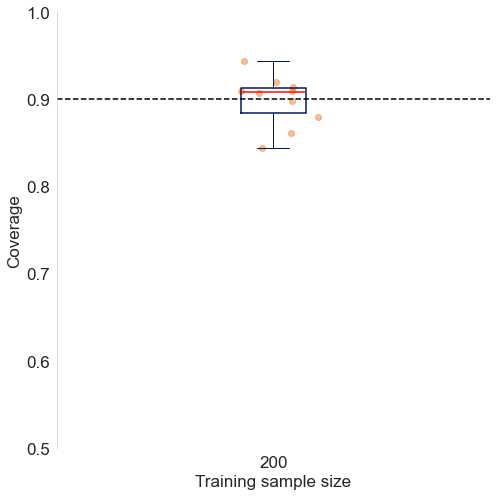

In [58]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([lc_ii_SPD_coverage_df_df_5_alpha_01, lc_ii_SPD_coverage_df_df_5_alpha_05, lc_ii_SPD_coverage_df_df_5_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    #data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    #data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        #'50': data_50['ai_ii_cov'].values,
        #'100': data_100['ai_ii_cov'].values,
        '200': data_200['lc_ii_cov'].values,
        #'500': data_500['ai_ii_cov'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    #sns.boxplot(data = data, x='train_size', y='II_coverage',
               # flierprops={"marker": "x"}, dodge=True, showmeans=True, meanprops={'marker':'o','markerfacecolor':'white','markeredgecolor':'white','markersize':'4'})

    ax.boxplot(boxplot_data, labels = ['200'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/lc_df_5_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/2788418457.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['200'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


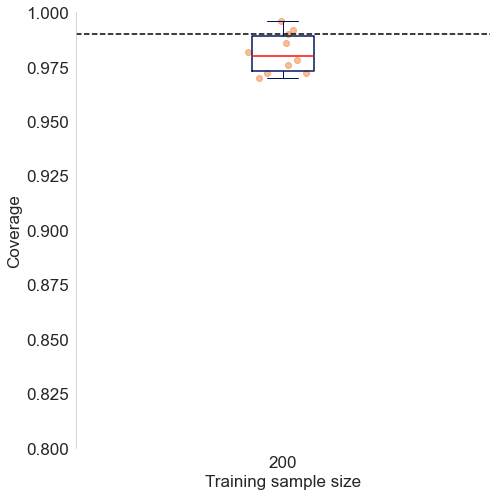

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/2788418457.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['200'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


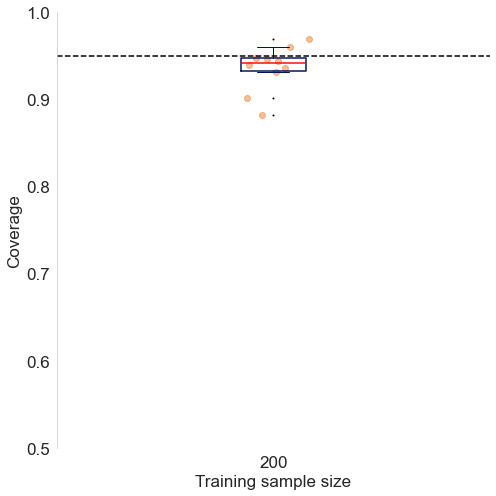

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/2788418457.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['200'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


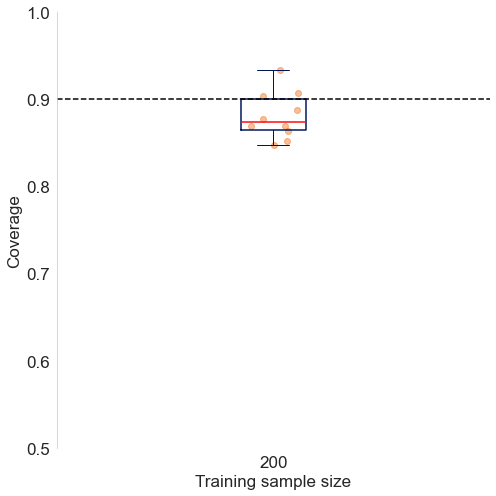

In [59]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([le_ii_SPD_coverage_df_df_5_alpha_01, le_ii_SPD_coverage_df_df_5_alpha_05, le_ii_SPD_coverage_df_df_5_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    #data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    #data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        #'50': data_50['ai_ii_cov'].values,
        #'100': data_100['ai_ii_cov'].values,
        '200': data_200['le_ii_cov'].values,
        #'500': data_500['ai_ii_cov'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    #sns.boxplot(data = data, x='train_size', y='II_coverage',
               # flierprops={"marker": "x"}, dodge=True, showmeans=True, meanprops={'marker':'o','markerfacecolor':'white','markeredgecolor':'white','markersize':'4'})

    ax.boxplot(boxplot_data, labels = ['200'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/le_df_5_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

## df 15

In [60]:
ai_ii_SPD_coverage_df_df_15_alpha_01 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()
ai_ii_SPD_coverage_df_df_15_alpha_05 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()
ai_ii_SPD_coverage_df_df_15_alpha_1  = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()

lc_ii_SPD_coverage_df_df_15_alpha_01 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()
lc_ii_SPD_coverage_df_df_15_alpha_05 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()
lc_ii_SPD_coverage_df_df_15_alpha_1  = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()

le_ii_SPD_coverage_df_df_15_alpha_01 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()
le_ii_SPD_coverage_df_df_15_alpha_05 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()
le_ii_SPD_coverage_df_df_15_alpha_1  = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()

ai_ii_SPD_coverage_df_df_15_alpha_01['ai_ii_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_ii_cov'].apply(lambda x: x[0])
ai_ii_SPD_coverage_df_df_15_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[0])

lc_ii_SPD_coverage_df_df_15_alpha_01['lc_ii_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_ii_cov'].apply(lambda x: x[0])
lc_ii_SPD_coverage_df_df_15_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[0])

le_ii_SPD_coverage_df_df_15_alpha_01['le_ii_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_ii_cov'].apply(lambda x: x[0])
le_ii_SPD_coverage_df_df_15_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[0])

ai_ii_SPD_coverage_df_df_15_alpha_05['ai_ii_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_ii_cov'].apply(lambda x: x[1])
ai_ii_SPD_coverage_df_df_15_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[1])

lc_ii_SPD_coverage_df_df_15_alpha_05['lc_ii_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_ii_cov'].apply(lambda x: x[1])
lc_ii_SPD_coverage_df_df_15_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[1])

le_ii_SPD_coverage_df_df_15_alpha_05['le_ii_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_ii_cov'].apply(lambda x: x[1])
le_ii_SPD_coverage_df_df_15_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[1])

ai_ii_SPD_coverage_df_df_15_alpha_1['ai_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_ii_cov'].apply(lambda x: x[2])
ai_ii_SPD_coverage_df_df_15_alpha_1['ai_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[2])

lc_ii_SPD_coverage_df_df_15_alpha_1['lc_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['lc_ii_cov'].apply(lambda x: x[2])
lc_ii_SPD_coverage_df_df_15_alpha_1['lc_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[2])

le_ii_SPD_coverage_df_df_15_alpha_1['le_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['le_ii_cov'].apply(lambda x: x[2])
le_ii_SPD_coverage_df_df_15_alpha_1['le_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[2])

ai_ii_SPD_coverage_df_df_15_alpha_01.head()
ai_ii_SPD_coverage_df_df_15_alpha_05.head()
ai_ii_SPD_coverage_df_df_15_alpha_1.head()

,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,ai_OOB_quantile
0,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.882,"[[1.0, 1.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.944, 0.88]",0.985606
3,50,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 0.0, ...",0.882,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.932, 0.874]",1.007730
6,500,15,"[[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [1.0, 1.0, ...",0.886,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.954, 0.92]",1.007677
7,50,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.966,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.96, 0.924, 0.91]",1.150025
8,100,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.930,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.978, 0.948, 0.924]",1.083789


/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/184053500.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


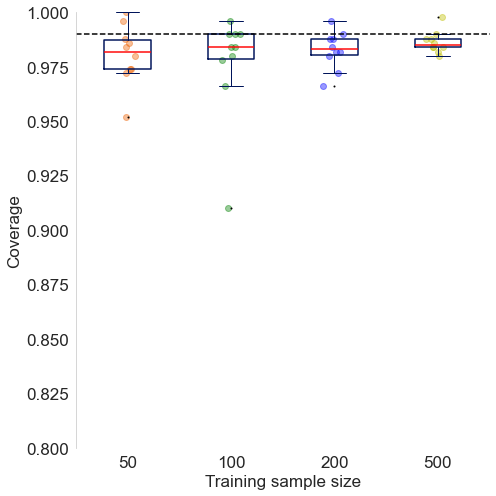

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/184053500.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


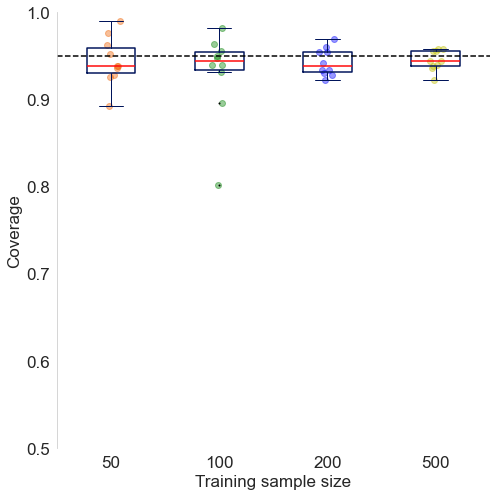

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/184053500.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


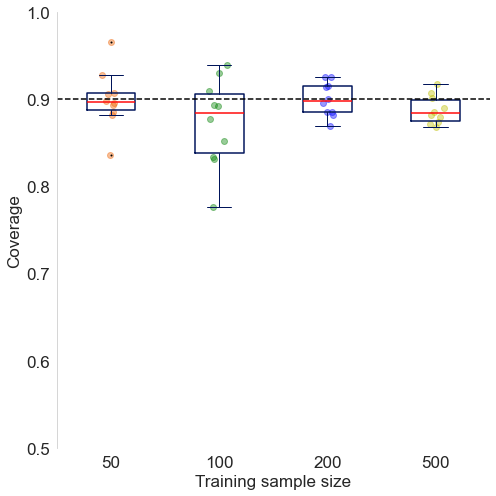

In [64]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([ai_ii_SPD_coverage_df_df_15_alpha_01, ai_ii_SPD_coverage_df_df_15_alpha_05, ai_ii_SPD_coverage_df_df_15_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['ai_ii_cov'].values,
        '100': data_100['ai_ii_cov'].values,
        '200': data_200['ai_ii_cov'].values,
        '500': data_500['ai_ii_cov'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/ai_df_15_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/671532780.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


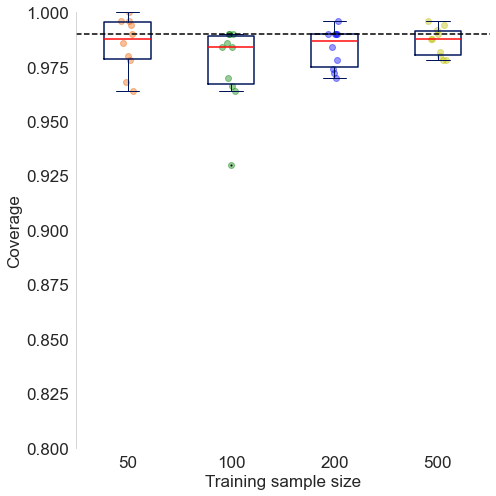

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/671532780.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


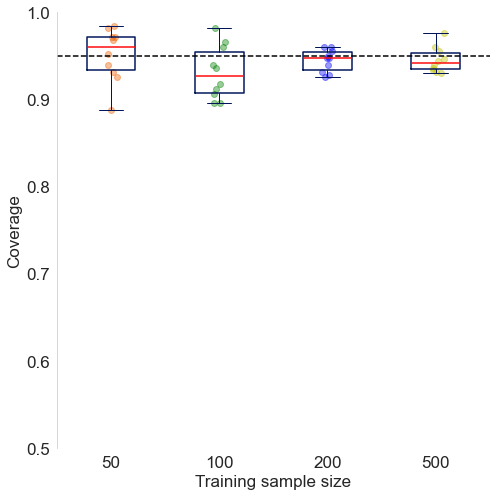

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/671532780.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


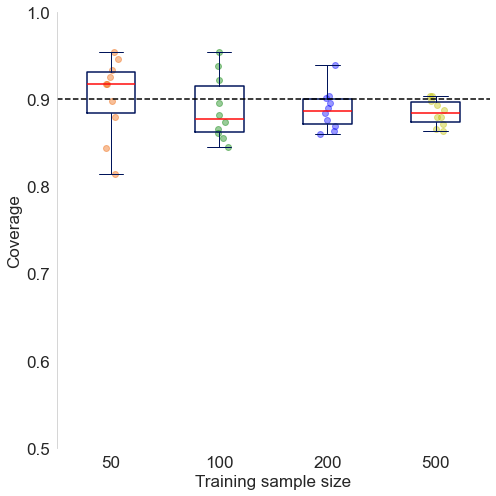

In [67]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([lc_ii_SPD_coverage_df_df_15_alpha_01, lc_ii_SPD_coverage_df_df_15_alpha_05, lc_ii_SPD_coverage_df_df_15_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['lc_ii_cov'].values,
        '100': data_100['lc_ii_cov'].values,
        '200': data_200['lc_ii_cov'].values,
        '500': data_500['lc_ii_cov'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/lc_df_15_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/2096507771.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


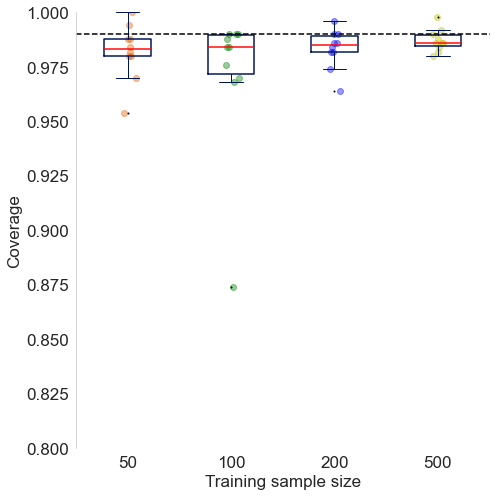

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/2096507771.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


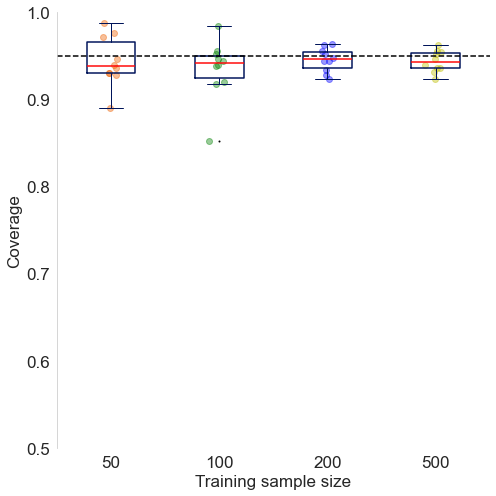

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/2096507771.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


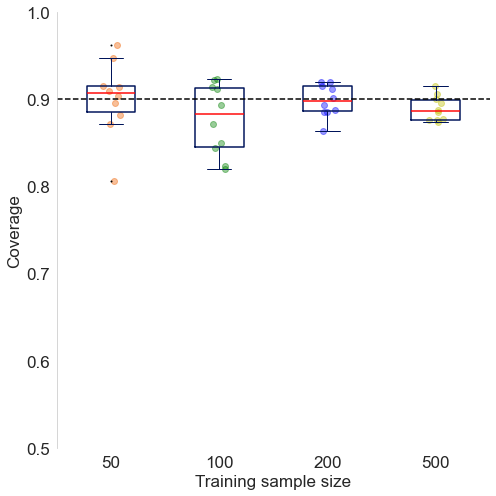

In [69]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([le_ii_SPD_coverage_df_df_15_alpha_01, le_ii_SPD_coverage_df_df_15_alpha_05, le_ii_SPD_coverage_df_df_15_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['le_ii_cov'].values,
        '100': data_100['le_ii_cov'].values,
        '200': data_200['le_ii_cov'].values,
        '500': data_500['le_ii_cov'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/le_df_5_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

# TYPE III

In [70]:
import pandas as pd
import numpy as np

zeros_init = np.zeros((50, 3))

def calculate_type_iii_coverage(SPD_coverage_df, sample_sizes, df_values):
    # Initialize a list to store the means for each row (50 rows of 3 means)
    ai_diccionario_iii = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    lc_diccionario_iii = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    le_diccionario_iii = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    for N in sample_sizes:
        for df in df_values:
            ai_means = []
            lc_means = []
            le_means = []
            ai_SPD_coverage_df_N_df = ai_SPD_coverage_df[(ai_SPD_coverage_df['df'] == str(df))
             & (ai_SPD_coverage_df['train_size'] == N)]
            lc_SPD_coverage_df_N_df = lc_SPD_coverage_df[(lc_SPD_coverage_df['df'] == str(df))
             & (lc_SPD_coverage_df['train_size'] == N)]
            le_SPD_coverage_df_N_df = le_SPD_coverage_df[(le_SPD_coverage_df['df'] == str(df))
             & (le_SPD_coverage_df['train_size'] == N)]
            # Loop through each of the 50 rows (indices 0 through 49)
            for i in range(50):
                # Extract the i-th row from each 50x3 DataFrame in SPD_coverage_df['i_cov']
                ai_row_data = ai_SPD_coverage_df_N_df['ai_iii_cov'].apply(lambda df: df[i])
                lc_row_data = lc_SPD_coverage_df_N_df['lc_iii_cov'].apply(lambda df: df[i])
                le_row_data = le_SPD_coverage_df_N_df['le_iii_cov'].apply(lambda df: df[i])
                # Calculate the mean of the 3 columns for this row (axis=0 is for columns)
                ai_row_mean = ai_row_data.mean(axis=0)
                lc_row_mean = lc_row_data.mean(axis=0)
                le_row_mean = le_row_data.mean(axis=0)
                # Append the mean of this row (3 values) to the list
                ai_means.append(ai_row_mean)
                lc_means.append(lc_row_mean)
                le_means.append(le_row_mean)

            ai_diccionario_iii['df_' + str(df)][str(N)] = ai_means
            lc_diccionario_iii['df_' + str(df)][str(N)] = lc_means
            le_diccionario_iii['df_' + str(df)][str(N)] = le_means
    # mean_df now contains the 50x3 means where each row corresponds to a row of means for the respective 
    return ai_diccionario_iii, lc_diccionario_iii, le_diccionario_iii

sample_sizes = [50, 100, 200, 500]  # Sample sizes
df_values = [5, 15]  # Concentration parameters

ai_diccionario_iii, lc_diccionario_iii, le_diccionario_iii = calculate_type_iii_coverage(SPD_coverage_df = SPD_coverage_df, sample_sizes = sample_sizes, df_values = df_values)
le_diccionario_iii

{'df_5': {'50': [array([0.9, 0.8, 0.8]),
   array([1. , 1. , 0.9]),
   array([1. , 1. , 0.8]),
   array([1., 1., 1.]),
   array([1. , 0.9, 0.9]),
   array([0.9, 0.9, 0.8]),
   array([0.8, 0.8, 0.8]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([1. , 0.9, 0.7]),
   array([1. , 1. , 0.9]),
   array([0.9, 0.7, 0.6]),
   array([1. , 0.9, 0.9]),
   array([0.9, 0.7, 0.7]),
   array([1. , 0.8, 0.7]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1. , 0.9, 0.9]),
   array([0.9, 0.9, 0.8]),
   array([1. , 0.9, 0.9]),
   array([1. , 0.9, 0.8]),
   array([0.8, 0.8, 0.8]),
   array([1., 1., 1.]),
   array([1. , 0.9, 0.9]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.7]),
   array([1. , 1. , 0.8]),
   array([1., 1., 1.]),
   array([1. , 0.9, 0.9]),
   array([1. , 0.8, 0.7]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),

Prediction balls

In [71]:
def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

In [72]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_ai = np.mean(ai_diccionario_iii[f'df_{df}'][str(N)], axis=0)
        stds_ai = np.sqrt(np.var(ai_diccionario_iii[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_ai[i]:.2f} ({100*stds_ai[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
ai_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
ai_df

Significance Level          0.01          0.05            0.1
df N                                                         
5  50               98.40 (4.18)  93.00 (8.54)  88.20 (10.33)
   100              98.40 (4.18)  96.00 (6.32)   90.40 (8.94)
   200              99.00 (3.00)  94.40 (7.79)  87.80 (10.25)
   500              98.60 (3.47)  95.00 (7.55)  89.40 (10.08)
15 50               99.00 (3.00)  96.40 (5.57)   93.20 (7.05)
   100              98.00 (4.00)  92.80 (8.26)   88.00 (9.17)
   200              98.60 (3.47)  94.20 (6.35)   89.60 (9.16)
   500              98.80 (3.25)  95.20 (5.74)   91.00 (8.54)

In [74]:
# Apply formatting to all cells
ai_df = ai_df.applymap(format_cell)
ai_latex = ai_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type III error', label='tab:ai_typeIIIerrorcoverage')
print(ai_latex)

\begin{table}
\caption{Type III error}
\label{tab:ai_typeIIIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.40 (4.18) & 93.00 (8.54) & 88.20 (10.33) \\
\textbf{} & \textbf{100} & 98.40 (4.18) & 96.00 (6.32) & 90.40 (8.94) \\
\textbf{} & \textbf{200} & 99.00 (3.00) & 94.40 (7.79) & 87.80 (10.25) \\
\textbf{} & \textbf{500} & 98.60 (3.47) & 95.00 (7.55) & 89.40 (10.08) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 99.00 (3.00) & 96.40 (5.57) & 93.20 (7.05) \\
\textbf{} & \textbf{100} & 98.00 (4.00) & 92.80 (8.26) & 88.00 (9.17) \\
\textbf{} & \textbf{200} & 98.60 (3.47) & 94.20 (6.35) & 89.60 (9.16) \\
\textbf{} & \textbf{500} & 98.80 (3.25) & 95.20 (5.74) & 91.00 (8.54) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/2564002804.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ai_df = ai_df.applymap(format_cell)


In [80]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_lc = np.mean(lc_diccionario_iii[f'df_{df}'][str(N)], axis=0)
        stds_lc = np.sqrt(np.var(lc_diccionario_iii[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_lc[i]:.2f} ({100*stds_lc[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
lc_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
lc_df

Significance Level          0.01          0.05            0.1
df N                                                         
5  50               98.60 (3.47)  94.20 (6.95)  87.20 (11.14)
   100              98.60 (4.00)  95.40 (7.27)   91.40 (8.49)
   200              99.20 (2.71)  95.40 (6.07)   90.40 (9.58)
   500              98.60 (3.47)  95.80 (5.69)   91.80 (9.31)
15 50               99.80 (1.40)  98.00 (4.47)   93.60 (6.86)
   100              98.80 (3.25)  95.80 (6.35)   91.60 (9.24)
   200              98.40 (3.67)  95.40 (6.07)   91.60 (7.58)
   500              99.00 (3.00)  97.80 (5.02)   95.20 (6.40)

In [81]:
# Apply formatting to all cells
lc_df = lc_df.applymap(format_cell)
lc_latex = lc_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type III error', label='tab:lc_typeIIIerrorcoverage')
print(lc_latex)

\begin{table}
\caption{Type III error}
\label{tab:lc_typeIIIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.60 (3.47) & 94.20 (6.95) & 87.20 (11.14) \\
\textbf{} & \textbf{100} & 98.60 (4.00) & 95.40 (7.27) & 91.40 (8.49) \\
\textbf{} & \textbf{200} & 99.20 (2.71) & 95.40 (6.07) & 90.40 (9.58) \\
\textbf{} & \textbf{500} & 98.60 (3.47) & 95.80 (5.69) & 91.80 (9.31) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 99.80 (1.40) & 98.00 (4.47) & 93.60 (6.86) \\
\textbf{} & \textbf{100} & 98.80 (3.25) & 95.80 (6.35) & 91.60 (9.24) \\
\textbf{} & \textbf{200} & 98.40 (3.67) & 95.40 (6.07) & 91.60 (7.58) \\
\textbf{} & \textbf{500} & 99.00 (3.00) & 97.80 (5.02) & 95.20 (6.40) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/587411137.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  lc_df = lc_df.applymap(format_cell)


In [82]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_le = np.mean(le_diccionario_iii[f'df_{df}'][str(N)], axis=0)
        stds_le = np.sqrt(np.var(le_diccionario_iii[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_le[i]:.2f} ({100*stds_le[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
le_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
le_df

Significance Level          0.01          0.05            0.1
df N                                                         
5  50               98.00 (4.90)  93.60 (8.19)  88.00 (10.77)
   100              98.20 (4.33)  95.20 (6.40)   89.20 (9.97)
   200              99.00 (3.00)  93.40 (9.08)   88.00 (9.38)
   500              98.60 (3.47)  95.00 (7.00)   89.00 (9.43)
15 50               99.00 (3.00)  96.40 (5.57)   91.20 (7.65)
   100              97.80 (4.60)  94.00 (6.93)   88.80 (8.86)
   200              98.60 (3.47)  94.00 (6.63)   89.40 (9.25)
   500              98.80 (3.25)  95.00 (5.74)   90.20 (8.83)

In [83]:
# Apply formatting to all cells
le_df = le_df.applymap(format_cell)
le_latex = le_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type III error', label='tab:ai_typeIIIerrorcoverage')
print(le_latex)

\begin{table}
\caption{Type III error}
\label{tab:ai_typeIIIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.00 (4.90) & 93.60 (8.19) & 88.00 (10.77) \\
\textbf{} & \textbf{100} & 98.20 (4.33) & 95.20 (6.40) & 89.20 (9.97) \\
\textbf{} & \textbf{200} & 99.00 (3.00) & 93.40 (9.08) & 88.00 (9.38) \\
\textbf{} & \textbf{500} & 98.60 (3.47) & 95.00 (7.00) & 89.00 (9.43) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 99.00 (3.00) & 96.40 (5.57) & 91.20 (7.65) \\
\textbf{} & \textbf{100} & 97.80 (4.60) & 94.00 (6.93) & 88.80 (8.86) \\
\textbf{} & \textbf{200} & 98.60 (3.47) & 94.00 (6.63) & 89.40 (9.25) \\
\textbf{} & \textbf{500} & 98.80 (3.25) & 95.00 (5.74) & 90.20 (8.83) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/142898499.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  le_df = le_df.applymap(format_cell)


# Type IV

Hacemos todo con $X=0.25$.

### df 5

In [84]:
ai_iv_SPD_coverage_df_df_5_alpha_01 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()
ai_iv_SPD_coverage_df_df_5_alpha_05 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()
ai_iv_SPD_coverage_df_df_5_alpha_1  = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()

lc_iv_SPD_coverage_df_df_5_alpha_01 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()
lc_iv_SPD_coverage_df_df_5_alpha_05 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()
lc_iv_SPD_coverage_df_df_5_alpha_1  = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()

le_iv_SPD_coverage_df_df_5_alpha_01 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()
le_iv_SPD_coverage_df_df_5_alpha_05 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()
le_iv_SPD_coverage_df_df_5_alpha_1  = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()

ai_iv_SPD_coverage_df_df_5_alpha_01['ai_iv_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_iv_cov'].apply(lambda x: x[0])
ai_iv_SPD_coverage_df_df_5_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[0])

lc_iv_SPD_coverage_df_df_5_alpha_01['lc_iv_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_iv_cov'].apply(lambda x: x[0])
lc_iv_SPD_coverage_df_df_5_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[0])

le_iv_SPD_coverage_df_df_5_alpha_01['le_iv_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_iv_cov'].apply(lambda x: x[0])
le_iv_SPD_coverage_df_df_5_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[0])

ai_iv_SPD_coverage_df_df_5_alpha_05['ai_iv_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_iv_cov'].apply(lambda x: x[1])
ai_iv_SPD_coverage_df_df_5_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[1])

lc_iv_SPD_coverage_df_df_5_alpha_05['lc_iv_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_iv_cov'].apply(lambda x: x[1])
lc_iv_SPD_coverage_df_df_5_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[1])

le_iv_SPD_coverage_df_df_5_alpha_05['le_iv_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_iv_cov'].apply(lambda x: x[1])
le_iv_SPD_coverage_df_df_5_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[1])

ai_iv_SPD_coverage_df_df_5_alpha_1['ai_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_iv_cov'].apply(lambda x: x[2])
ai_iv_SPD_coverage_df_df_5_alpha_1['ai_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[2])

lc_iv_SPD_coverage_df_df_5_alpha_1['lc_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['lc_iv_cov'].apply(lambda x: x[2])
lc_iv_SPD_coverage_df_df_5_alpha_1['lc_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[2])

le_iv_SPD_coverage_df_df_5_alpha_1['le_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['le_iv_cov'].apply(lambda x: x[2])
le_iv_SPD_coverage_df_df_5_alpha_1['le_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[2])

ai_iv_SPD_coverage_df_df_5_alpha_01.head()
ai_iv_SPD_coverage_df_df_5_alpha_05.head()
ai_iv_SPD_coverage_df_df_5_alpha_1.head()

,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,ai_OOB_quantile
1,200,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.938, 0.876]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.882,1.783701
2,200,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.974, 0.946, 0.884]","[[1.0, 1.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.866,1.865951
4,100,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.976, 0.934]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.922,2.054094
5,500,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.934, 0.894]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.914,1.950285
10,50,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.958, 0.848]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.792,1.765177


/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/3068595669.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


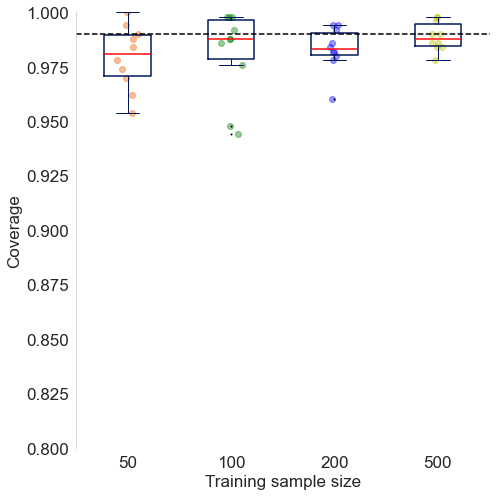

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/3068595669.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


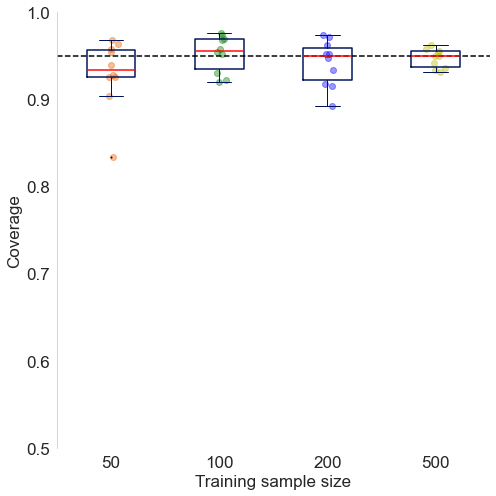

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/3068595669.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


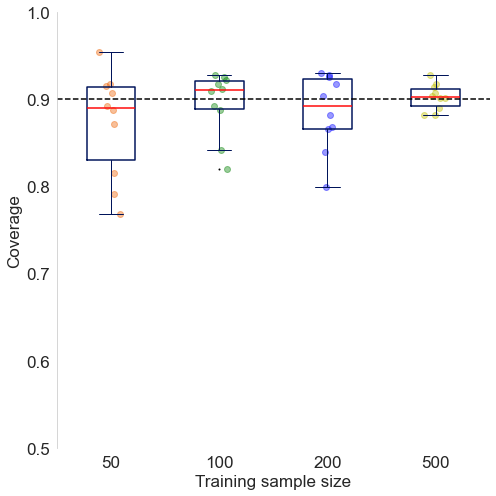

In [85]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([ai_iv_SPD_coverage_df_df_5_alpha_01, ai_iv_SPD_coverage_df_df_5_alpha_05, ai_iv_SPD_coverage_df_df_5_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, there should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['ai_iv_cov'].values,
        '100': data_100['ai_iv_cov'].values,
        '200': data_200['ai_iv_cov'].values,
        '500': data_500['ai_iv_cov'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/ai_df_5_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/803225704.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


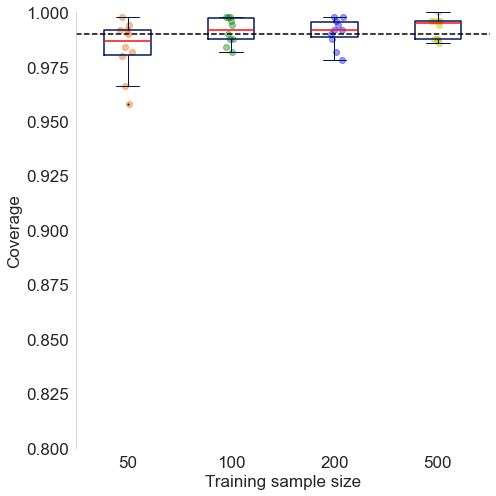

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/803225704.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


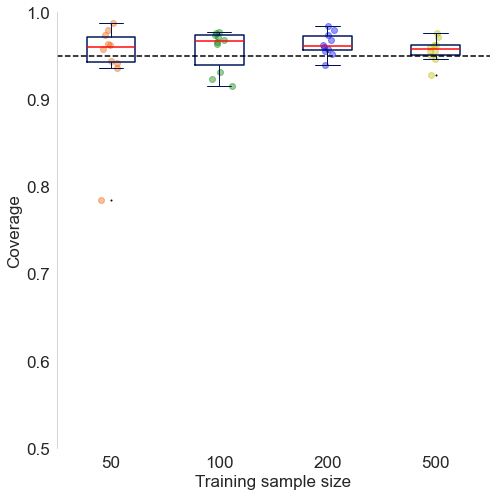

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/803225704.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


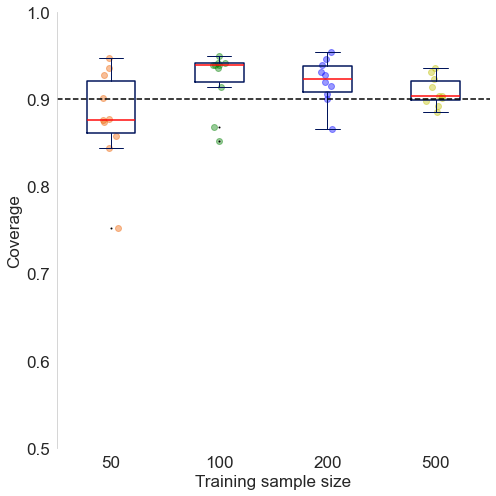

In [86]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([lc_iv_SPD_coverage_df_df_5_alpha_01, lc_iv_SPD_coverage_df_df_5_alpha_05, lc_iv_SPD_coverage_df_df_5_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['lc_iv_cov'].values,
        '100': data_100['lc_iv_cov'].values,
        '200': data_200['lc_iv_cov'].values,
        '500': data_500['lc_iv_cov'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/lc_df_5_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/4270824227.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


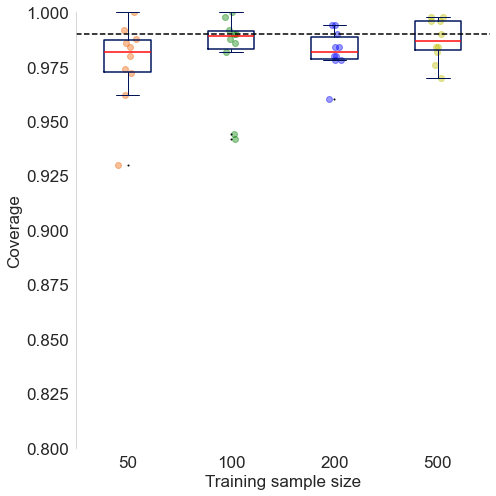

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/4270824227.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


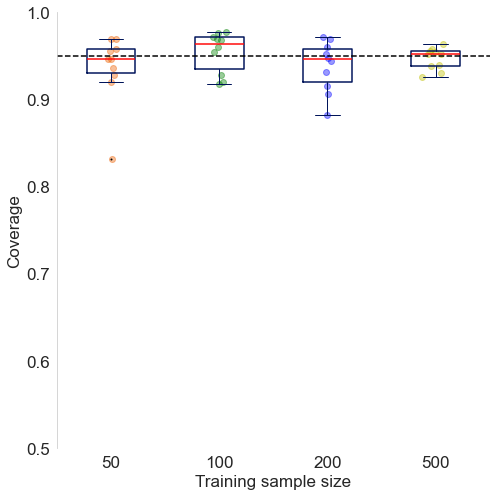

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/4270824227.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


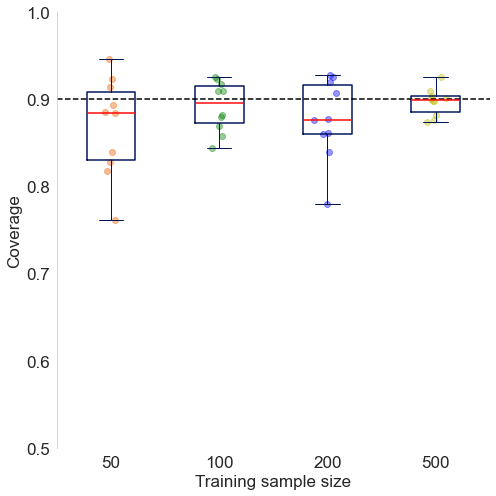

In [88]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([le_iv_SPD_coverage_df_df_5_alpha_01, le_iv_SPD_coverage_df_df_5_alpha_05, le_iv_SPD_coverage_df_df_5_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['le_iv_cov'].values,
        '100': data_100['le_iv_cov'].values,
        '200': data_200['le_iv_cov'].values,
        '500': data_500['le_iv_cov'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/le_df_5_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

## df 15

In [89]:
ai_iv_SPD_coverage_df_df_15_alpha_01 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()
ai_iv_SPD_coverage_df_df_15_alpha_05 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()
ai_iv_SPD_coverage_df_df_15_alpha_1  = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()

lc_iv_SPD_coverage_df_df_15_alpha_01 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()
lc_iv_SPD_coverage_df_df_15_alpha_05 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()
lc_iv_SPD_coverage_df_df_15_alpha_1  = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()

le_iv_SPD_coverage_df_df_15_alpha_01 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()
le_iv_SPD_coverage_df_df_15_alpha_05 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()
le_iv_SPD_coverage_df_df_15_alpha_1  = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()

ai_iv_SPD_coverage_df_df_15_alpha_01['ai_iv_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_iv_cov'].apply(lambda x: x[0])
ai_iv_SPD_coverage_df_df_15_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[0])

lc_iv_SPD_coverage_df_df_15_alpha_01['lc_iv_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_iv_cov'].apply(lambda x: x[0])
lc_iv_SPD_coverage_df_df_15_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[0])

le_iv_SPD_coverage_df_df_15_alpha_01['le_iv_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_iv_cov'].apply(lambda x: x[0])
le_iv_SPD_coverage_df_df_15_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[0])

ai_iv_SPD_coverage_df_df_15_alpha_05['ai_iv_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_iv_cov'].apply(lambda x: x[1])
ai_iv_SPD_coverage_df_df_15_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[1])

lc_iv_SPD_coverage_df_df_15_alpha_05['lc_iv_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_iv_cov'].apply(lambda x: x[1])
lc_iv_SPD_coverage_df_df_15_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[1])

le_iv_SPD_coverage_df_df_15_alpha_05['le_iv_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_iv_cov'].apply(lambda x: x[1])
le_iv_SPD_coverage_df_df_15_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[1])

ai_iv_SPD_coverage_df_df_15_alpha_1['ai_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_iv_cov'].apply(lambda x: x[2])
ai_iv_SPD_coverage_df_df_15_alpha_1['ai_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[2])

lc_iv_SPD_coverage_df_df_15_alpha_1['lc_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['lc_iv_cov'].apply(lambda x: x[2])
lc_iv_SPD_coverage_df_df_15_alpha_1['lc_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[2])

le_iv_SPD_coverage_df_df_15_alpha_1['le_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['le_iv_cov'].apply(lambda x: x[2])
le_iv_SPD_coverage_df_df_15_alpha_1['le_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[2])

ai_iv_SPD_coverage_df_df_15_alpha_01.head()
ai_iv_SPD_coverage_df_df_15_alpha_05.head()
ai_iv_SPD_coverage_df_df_15_alpha_1.head()

,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,ai_OOB_quantile
0,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.934, 0.882]","[[1.0, 1.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.880,0.985606
3,50,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 0.0, ...","[0.98, 0.936, 0.882]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.874,1.007730
6,500,15,"[[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [1.0, 1.0, ...","[0.982, 0.936, 0.886]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.920,1.007677
7,50,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.976, 0.966]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.910,1.150025
8,100,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.964, 0.93]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.924,1.083789


/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/207175910.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


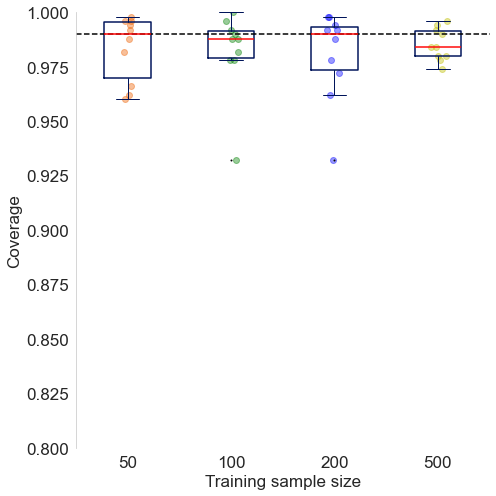

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/207175910.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


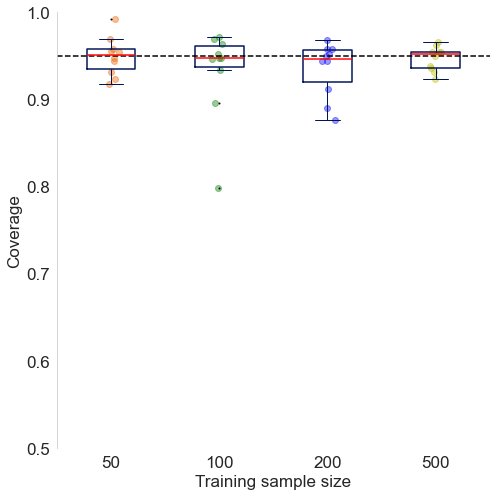

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/207175910.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


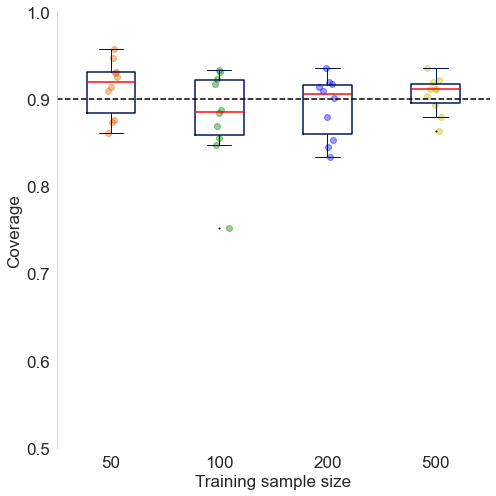

In [90]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([ai_iv_SPD_coverage_df_df_15_alpha_01, ai_iv_SPD_coverage_df_df_15_alpha_05, ai_iv_SPD_coverage_df_df_15_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['ai_iv_cov'].values,
        '100': data_100['ai_iv_cov'].values,
        '200': data_200['ai_iv_cov'].values,
        '500': data_500['ai_iv_cov'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"
    
    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/ai_df_15_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/2879942792.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


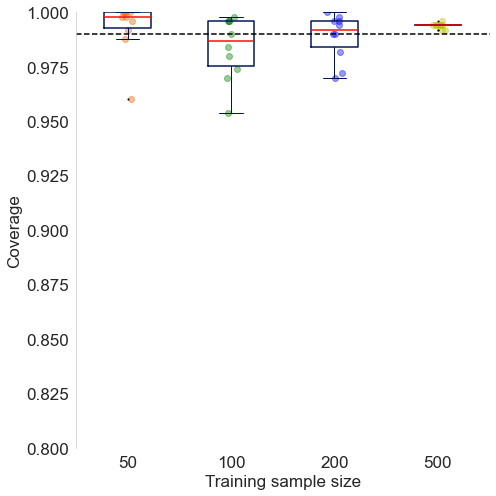

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/2879942792.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


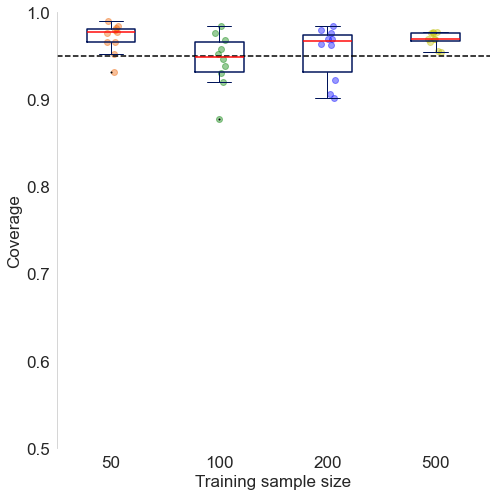

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/2879942792.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


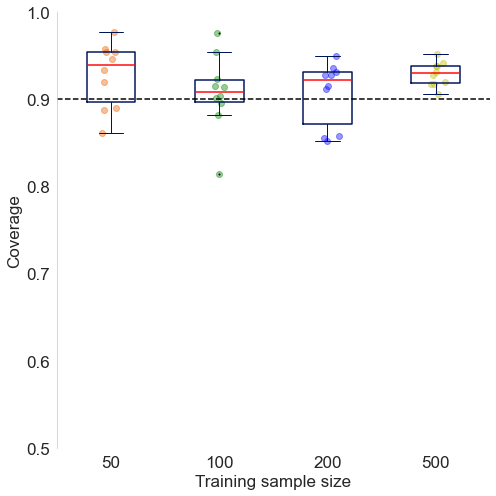

In [92]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([lc_iv_SPD_coverage_df_df_15_alpha_01, lc_iv_SPD_coverage_df_df_15_alpha_05, lc_iv_SPD_coverage_df_df_15_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['lc_iv_cov'].values,
        '100': data_100['lc_iv_cov'].values,
        '200': data_200['lc_iv_cov'].values,
        '500': data_500['lc_iv_cov'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/lc_df_15_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/1655411716.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


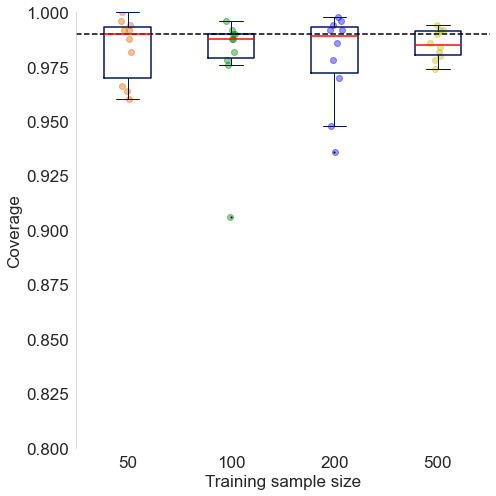

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/1655411716.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


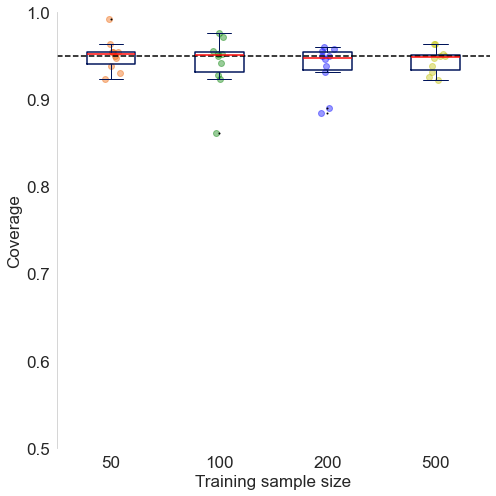

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_45378/1655411716.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


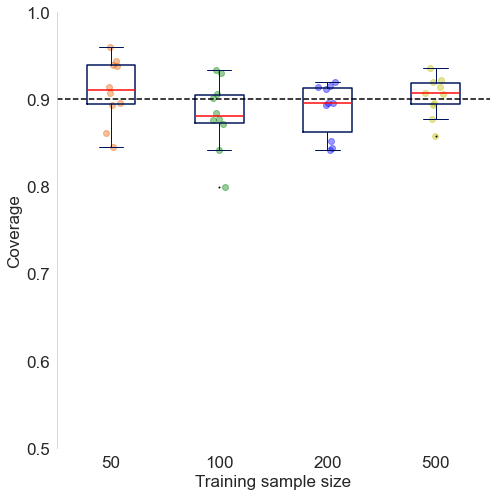

In [93]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([le_iv_SPD_coverage_df_df_15_alpha_01, le_iv_SPD_coverage_df_df_15_alpha_05, le_iv_SPD_coverage_df_df_15_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['le_iv_cov'].values,
        '100': data_100['le_iv_cov'].values,
        '200': data_200['le_iv_cov'].values,
        '500': data_500['le_iv_cov'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/le_df_15_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

In [176]:
def check_inputs(A, B):
    if not isinstance(A, np.ndarray) or not isinstance(B, np.ndarray):
        raise ValueError("Inputs must be ndarrays")
    if not A.shape == B.shape:
        raise ValueError("Inputs must have equal dimensions")
    if A.ndim < 2:
        raise ValueError("Inputs must be at least a 2D ndarray")

def distance_logeuclid(S1, S2):
    return np.linalg.norm(logm(S1) - logm(S2), ord='fro', axis=(-2, -1))

In [177]:
from geomstats.geometry.spd_matrices import SPDMatrices, SPDMetricLogEuclidean
from geomstats.learning.frechet_mean import FrechetMean

# create 2 random SPD matrices
n = 2
dim = 3
#A must be SPD

A = np.random.rand(dim, dim)
A = np.dot(A, A.transpose())
B = np.random.rand(dim, dim)
B = np.dot(B, B.transpose())
le_metric = SPDMetricLogEuclidean(dim)
frechet_mean = FrechetMean(metric=le_metric)
for _ in range(10000):
    distance_logeuclid(A,B)


In [127]:
le_metric = SPDMetricLogEuclidean(dim)
frechet_mean = FrechetMean(metric=le_metric)
le_metric.dist(A, B)

10.541663855004034

In [179]:
for _ in range(10000):
    le_metric.dist(A,B)